<a href="https://colab.research.google.com/github/mahidhargubbala-pixel/student-performance-analysis/blob/main/eda_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA) — Student Performance

## Objective
Analyze student performance data to uncover patterns,
correlations, and key factors influencing academic success.

## Methodology
- Statistical summaries (mean, median, distribution)
- Correlation analysis between numeric features
- Group-wise comparisons (Gender, Parental Education)
- Visual pattern discovery (histograms, scatter plots,
  boxplots, pairplots)

## Key Findings
1. **Study Hours** is the strongest predictor of academic
   performance (correlation ≈ 0.6+), far ahead of any
   other factor.
2. **Attendance** shows a clear positive relationship with
   scores — students above 90% attendance significantly
   outperform those below 60%.
3. **Parental Education** has a moderate positive influence;
   students with higher-educated parents tend to score
   slightly better.
4. **Gender** shows almost no difference in performance —
   the gap is statistically negligible.

## Conclusion
Behavioral factors (study habits, attendance) matter far
more than demographic factors in determining student
success. This suggests interventions should focus on
improving study habits and attendance rather than
demographic-based programs.

**Tools used:** Python, Pandas, Matplotlib, Seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 200

attendance = np.random.randint(50, 101, n)
study_hours = np.round(np.random.uniform(0.5, 8, n), 1)
parental_edu_num = np.random.choice([0,1,2,3], n, p=[0.30,0.35,0.20,0.15])
gender = np.random.choice(["Male","Female"], n)
age = np.random.randint(15, 22, n)

base_score = (
    0.45 * attendance +
    5.5 * study_hours +
    3 * parental_edu_num +
    np.random.normal(0, 8, n)
)
avg_score = np.clip(base_score / 1.1, 0, 100).round(2)

edu_labels = {0:"High School", 1:"Bachelor", 2:"Master", 3:"PhD"}

df = pd.DataFrame({
    "StudentID": [f"S{str(i).zfill(3)}" for i in range(1, n+1)],
    "Gender": gender,
    "Age": age,
    "Attendance": attendance,
    "StudyHours": study_hours,
    "ParentalEdu": [edu_labels[x] for x in parental_edu_num],
    "AverageScore": avg_score
})
df["PassFail"] = df["AverageScore"].apply(lambda x: "Pass" if x >= 50 else "Fail")

print("Dataset ready:", df.shape)
df.head()

Dataset ready: (200, 8)


,StudentID,Gender,Age,Attendance,StudyHours,ParentalEdu,AverageScore,PassFail
0,S001,Male,17,88,4.1,High School,71.03,Pass
1,S002,Male,21,78,5.7,High School,48.92,Fail
2,S003,Male,21,64,2.5,Bachelor,32.61,Fail
3,S004,Female,20,92,2.3,High School,37.40,Fail
4,S005,Male,17,57,1.8,High School,26.88,Fail


In [2]:
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("Statistical Summary:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   StudentID     200 non-null    object 
 1   Gender        200 non-null    object 
 2   Age           200 non-null    int64  
 3   Attendance    200 non-null    int64  
 4   StudyHours    200 non-null    float64
 5   ParentalEdu   200 non-null    object 
 6   AverageScore  200 non-null    float64
 7   PassFail      200 non-null    object 
dtypes: float64(2), int64(2), object(4)
memory usage: 12.6+ KB
None

Statistical Summary:


,Age,Attendance,StudyHours,AverageScore
count,200.000000,200.000000,200.000000,200.000000
mean,18.075000,74.635000,4.242500,55.394250
std,2.012368,14.656598,2.141395,15.475515
min,15.000000,50.000000,0.500000,13.930000
25%,16.000000,62.000000,2.400000,45.335000
50%,18.000000,75.000000,4.100000,54.695000
75%,20.000000,88.000000,5.900000,67.857500
max,21.000000,100.000000,8.000000,100.000000


In [3]:
print("Gender distribution:")
print(df["Gender"].value_counts())

print("\nParental Education distribution:")
print(df["ParentalEdu"].value_counts())

print("\nPass/Fail distribution:")
print(df["PassFail"].value_counts())
print(df["PassFail"].value_counts(normalize=True).round(2) * 100)

Gender distribution:
Gender
Male      103
Female     97
Name: count, dtype: int64

Parental Education distribution:
ParentalEdu
Bachelor       70
High School    60
Master         38
PhD            32
Name: count, dtype: int64

Pass/Fail distribution:
PassFail
Pass    123
Fail     77
Name: count, dtype: int64
PassFail
Pass    62.0
Fail    38.0
Name: proportion, dtype: float64


In [4]:
print("Average Score by Gender:")
print(df.groupby("Gender")["AverageScore"].mean().round(2))

print("\nAverage Score by Parental Education:")
print(df.groupby("ParentalEdu")["AverageScore"].mean().round(2).sort_values(ascending=False))

print("\nAverage Score by Pass/Fail:")
print(df.groupby("PassFail")[["Attendance","StudyHours"]].mean().round(2))

Average Score by Gender:
Gender
Female    55.20
Male      55.58
Name: AverageScore, dtype: float64

Average Score by Parental Education:
ParentalEdu
PhD            61.74
Bachelor       57.01
Master         55.41
High School    50.12
Name: AverageScore, dtype: float64

Average Score by Pass/Fail:
          Attendance  StudyHours
PassFail                        
Fail           67.90        2.52
Pass           78.85        5.32


In [5]:
print("Average Score by Gender:")
print(df.groupby("Gender")["AverageScore"].mean().round(2))

print("\nAverage Score by Parental Education:")
print(df.groupby("ParentalEdu")["AverageScore"].mean().round(2).sort_values(ascending=False))

print("\nAverage Score by Pass/Fail:")
print(df.groupby("PassFail")[["Attendance","StudyHours"]].mean().round(2))

Average Score by Gender:
Gender
Female    55.20
Male      55.58
Name: AverageScore, dtype: float64

Average Score by Parental Education:
ParentalEdu
PhD            61.74
Bachelor       57.01
Master         55.41
High School    50.12
Name: AverageScore, dtype: float64

Average Score by Pass/Fail:
          Attendance  StudyHours
PassFail                        
Fail           67.90        2.52
Pass           78.85        5.32


In [6]:
numeric_cols = ["Age", "Attendance", "StudyHours", "AverageScore"]
corr_matrix = df[numeric_cols].corr()
print(corr_matrix.round(2))

               Age  Attendance  StudyHours  AverageScore
Age           1.00       -0.19       -0.01         -0.12
Attendance   -0.19        1.00        0.01          0.45
StudyHours   -0.01        0.01        1.00          0.71
AverageScore -0.12        0.45        0.71          1.00


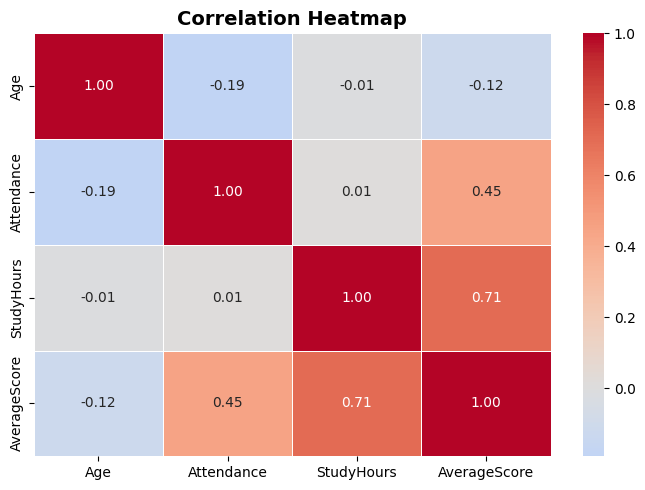

In [7]:
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [8]:
corr_with_score = corr_matrix["AverageScore"].drop("AverageScore").sort_values(ascending=False)
print("Correlation of each factor with AverageScore:")
print(corr_with_score)

strongest = corr_with_score.idxmax()
print(f"\n👉 Strongest influencing factor: {strongest} (correlation = {corr_with_score.max():.2f})")

Correlation of each factor with AverageScore:
StudyHours    0.710050
Attendance    0.449393
Age          -0.117549
Name: AverageScore, dtype: float64

👉 Strongest influencing factor: StudyHours (correlation = 0.71)


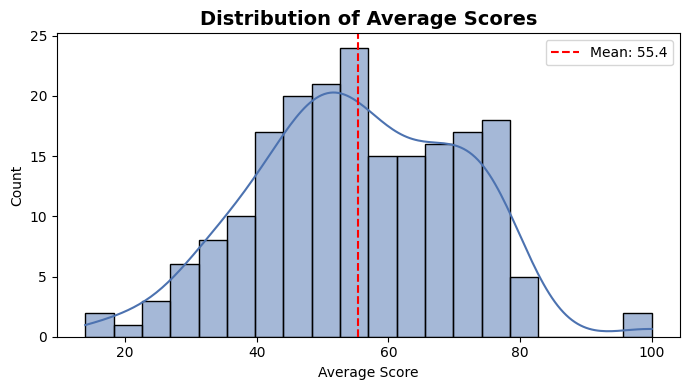

In [9]:
plt.figure(figsize=(7, 4))
sns.histplot(df["AverageScore"], bins=20, kde=True, color="#4C72B0")
plt.axvline(df["AverageScore"].mean(), color="red", linestyle="--", label=f"Mean: {df['AverageScore'].mean():.1f}")
plt.title("Distribution of Average Scores", fontsize=14, fontweight="bold")
plt.xlabel("Average Score")
plt.legend()
plt.tight_layout()
plt.show()

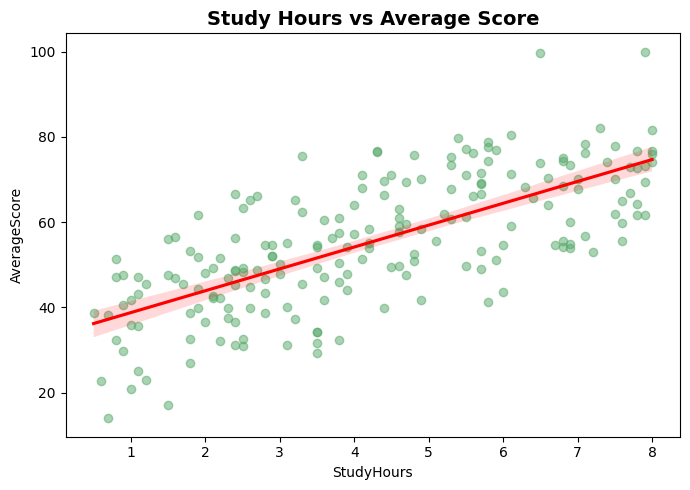

In [10]:
plt.figure(figsize=(7, 5))
sns.regplot(data=df, x="StudyHours", y="AverageScore",
            scatter_kws={"alpha":0.5, "color":"#55A868"},
            line_kws={"color":"red"})
plt.title("Study Hours vs Average Score", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

/tmp/ipykernel_5089/1510584727.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="AttendanceBand", y="AverageScore", palette="viridis")


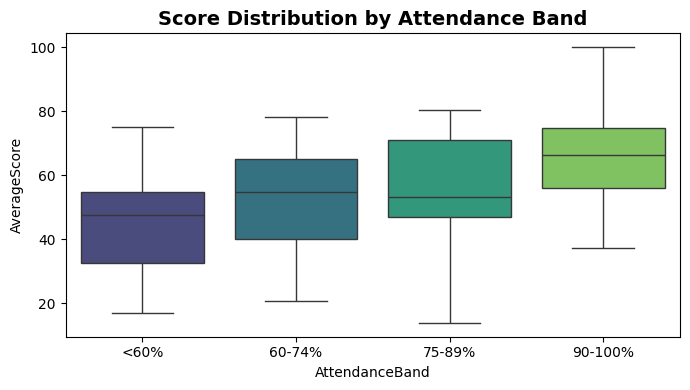

In [11]:
df["AttendanceBand"] = pd.cut(df["Attendance"], bins=[0,59,74,89,100],
                                labels=["<60%","60-74%","75-89%","90-100%"])

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="AttendanceBand", y="AverageScore", palette="viridis")
plt.title("Score Distribution by Attendance Band", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

/tmp/ipykernel_5089/533227585.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="ParentalEdu", y="AverageScore", order=edu_order, palette="crest")


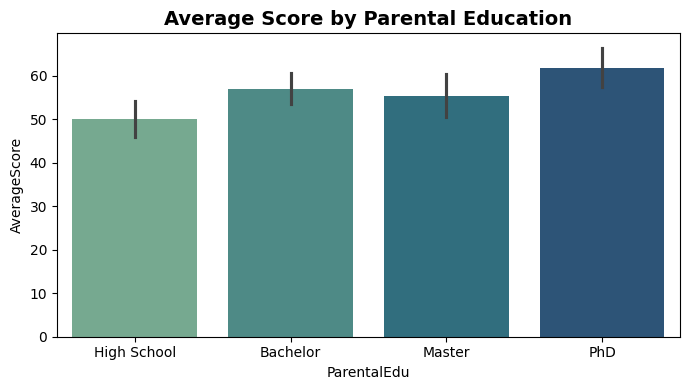

In [12]:
edu_order = ["High School","Bachelor","Master","PhD"]
plt.figure(figsize=(7, 4))
sns.barplot(data=df, x="ParentalEdu", y="AverageScore", order=edu_order, palette="crest")
plt.title("Average Score by Parental Education", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

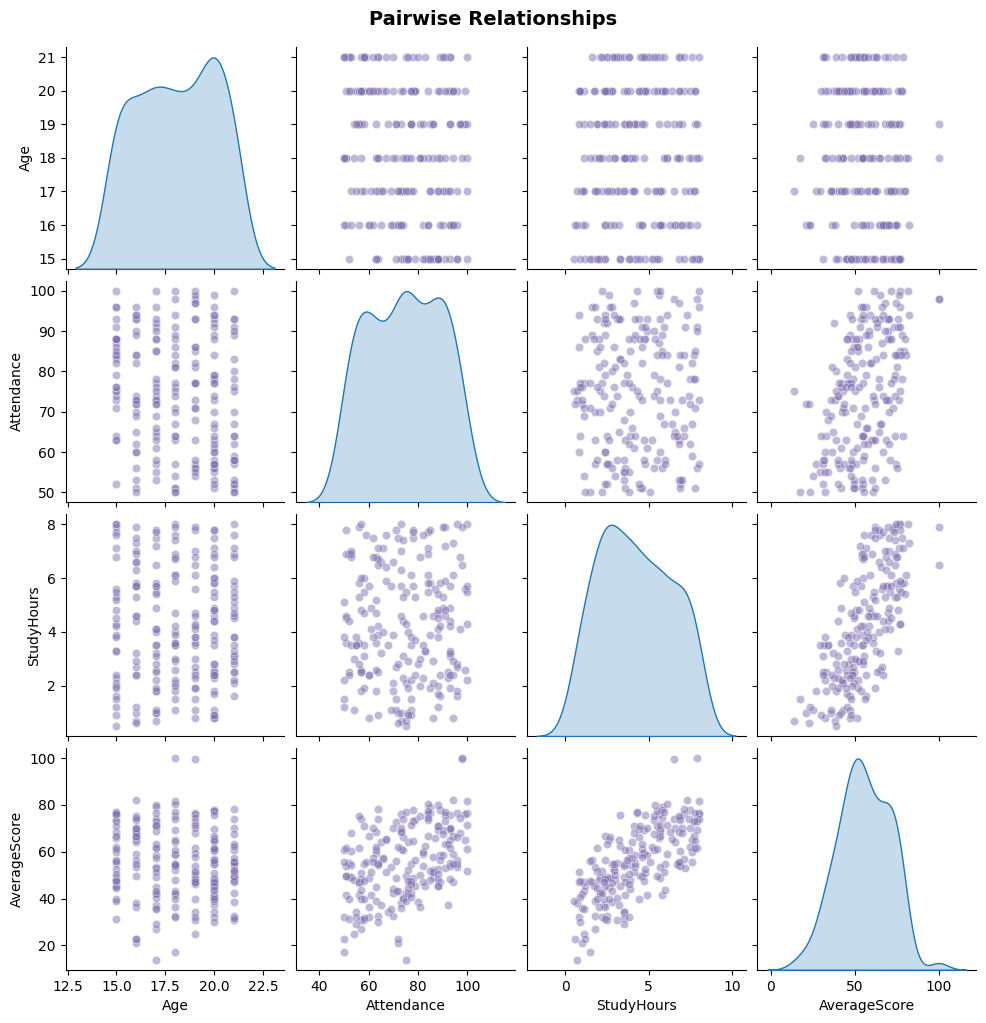

In [13]:
sns.pairplot(df[["Age","Attendance","StudyHours","AverageScore"]], diag_kind="kde",
             plot_kws={"alpha":0.5, "color":"#8172B2"})
plt.suptitle("Pairwise Relationships", y=1.02, fontsize=14, fontweight="bold")
plt.show()

In [14]:
print("="*55)
print("   EXPLORATORY DATA ANALYSIS — KEY INSIGHTS")
print("="*55)

print(f"\n1. Dataset Overview")
print(f"   Total Students Analyzed : {len(df)}")
print(f"   Pass Rate                : {(df['PassFail']=='Pass').mean()*100:.1f}%")
print(f"   Average Score            : {df['AverageScore'].mean():.1f}/100")

print(f"\n2. Strongest Influencing Factor")
print(f"   Study Hours correlation with score : {corr_with_score['StudyHours']:.2f}")
print(f"   Attendance correlation with score  : {corr_with_score['Attendance']:.2f}")

print(f"\n3. Group Patterns")
top_edu = df.groupby('ParentalEdu')['AverageScore'].mean().idxmax()
print(f"   Highest-scoring Parental Education group : {top_edu}")

gender_gap = abs(df.groupby('Gender')['AverageScore'].mean().diff().iloc[-1])
print(f"   Gender score gap                          : {gender_gap:.2f} points (minimal)")

print(f"\n4. Attendance Threshold")
high_att = df[df['Attendance']>=90]['AverageScore'].mean()
low_att = df[df['Attendance']<60]['AverageScore'].mean()
print(f"   Avg score (90-100% attendance) : {high_att:.1f}")
print(f"   Avg score (<60% attendance)    : {low_att:.1f}")
print("="*55)

   EXPLORATORY DATA ANALYSIS — KEY INSIGHTS

1. Dataset Overview
   Total Students Analyzed : 200
   Pass Rate                : 61.5%
   Average Score            : 55.4/100

2. Strongest Influencing Factor
   Study Hours correlation with score : 0.71
   Attendance correlation with score  : 0.45

3. Group Patterns
   Highest-scoring Parental Education group : PhD
   Gender score gap                          : 0.38 points (minimal)

4. Attendance Threshold
   Avg score (90-100% attendance) : 66.2
   Avg score (<60% attendance)    : 46.1


In [15]:
df.to_csv("eda_student_data.csv", index=False)
print("✅ Dataset saved!")

✅ Dataset saved!
